# CART 决策树：从原理到实战

**算法分享 | 机器学习与深度学习课程**

---

## 大纲

| # | 内容 |
|---|------|
| 1 | 决策树的基本原理 |
| 2 | ID3 / C4.5 / CART 的发展与区别 |
| 3 | 实战：Titanic 生存预测 |


---
## 1. 决策树：像人一样做判断

### 核心思想

决策树模拟人类的「一问一答」过程：从根节点出发，每个内部节点对一个特征提问，根据答案走向不同的分支，最终在叶节点给出预测结果。

**示例**：根据天气特征判断今天是否适合出门骑行（二分类：适合 ✅ / 不适合 ❌）

```
            [今天是晴天？]
           /              \
         是                 否
        /                     \
[风力 > 5 级？]           [不适合 ❌]
  /         \
是            否
/               \
[不适合 ❌]   [适合 ✅]
```

规则完全符合直觉：晴天且风不大 → 适合骑行；阴天或大风 → 不适合。

---

### 构建过程：递归二分

1. **从所有特征中选出最优的切分特征和切分阈值**（节点纯度提升最大）
2. **把当前节点的样本一分为二**，左边满足条件，右边不满足
3. **对左右子节点递归重复步骤 1-2**，直到满足停止条件

**停止条件**（任意一个满足即停止）：
- 节点内所有样本属于同一类别（叶节点已纯）
- 树深度达到 `max_depth` 上限
- 节点样本数不足 `min_samples_split`

---

### 决策树能做哪些任务？

| 任务 | 叶节点输出 | 常用不纯度度量 | 典型例子 |
|------|-----------|--------------|----------|
| **分类** | 多数类的类别标签 | Gini / 信息熵 | 垃圾邮件识别、病患诊断 |
| **回归** | 样本目标值的均值 | 均方误差（MSE） | 房价预测、销量预测 |

> 两种任务的树结构完全相同，区别只在叶节点的输出方式和分裂准则。

---

### 什么是「节点纯度」？

分裂的目标是让分裂后的子节点尽量**纯**——子节点内的样本尽量属于同一类。

**直觉类比**：把一堆红球和蓝球分成两堆，最好的分法是一堆全红、一堆全蓝，而不是两堆都混着。

三种算法（ID3、C4.5、CART）的核心区别，就在于如何**量化这个「纯度」**。


---
## 2. ID3 → C4.5 → CART：三代算法的演进

### 2.1 ID3（1986）—— 信息增益

**用「香农熵」衡量节点的不纯度：**

$$H(S) = -\sum_{c} P(c) \cdot \log_2 P(c)$$

- 节点全是同一类 → 熵 = 0（最纯）
- 各类均匀分布 → 熵最大（最乱，二分类时熵 = 1.0）

**分裂准则：最大化信息增益（IG）**

$$IG = H(父节点) - \sum_{子节点} \frac{|S_i|}{|S|} \cdot H(S_i)$$

**致命缺陷：偏爱取值数量多的特征。**

极端例子：用「乘客ID」（每人唯一）做特征，分裂后每个叶节点只有 1 个样本，熵全为 0，IG 最大——但这个分法毫无泛化能力，完全是在「记住」训练数据。

---

### 2.2 C4.5（1993）—— 增益率

**在 IG 基础上除以「分裂信息量」来惩罚多值特征：**

$$GR = \frac{IG}{IV}, \quad IV = -\sum_i \frac{|S_i|}{|S|} \cdot \log_2 \frac{|S_i|}{|S|}$$

- IV（内在值）越大，说明分裂越均匀、分支越多 → GR 被压低
- 这样高基数特征（取值多的特征）不再自动获得高分

**改进：** 支持连续特征（枚举切分阈值）、支持缺失值

**局限：** 仍可能生成多叉树，树的形状不固定

---

### 2.3 CART（1984）—— Gini 不纯度 + 强制二叉树

CART（Classification And Regression Trees）实际上早于 C4.5，但在工程上更成熟，是目前主流实现（包括 sklearn）的标准。

**用「Gini 不纯度」衡量节点纯度：**

$$Gini(S) = 1 - \sum_{c} P(c)^2$$

**直觉**：从节点随机取两个样本，两者类别不同的概率。节点越纯，这个概率越低。

二分类简化：$Gini = 2p(1-p)$，其中 $p$ 是正类比例。

**分裂准则：最大化 Gini 减少量（ΔGini）**

$$\Delta Gini = Gini(父节点) - \frac{|L|}{|S|} \cdot Gini(L) - \frac{|R|}{|S|} \cdot Gini(R)$$

**核心设计：永远只做二叉分裂**，无论特征是连续还是离散：
- 连续特征：枚举所有相邻值的均值作为候选阈值
- 离散特征：也转化为「≤ 某值」vs「> 某值」的二分问题

---

### 三种算法对比总结

| 维度 | ID3 | C4.5 | CART |
|------|-----|------|------|
| **发布年份** | 1986 | 1993 | 1984 |
| **不纯度度量** | 信息熵（Shannon Entropy） | 信息熵 | Gini 不纯度 |
| **分裂准则** | 信息增益（IG） | 增益率（GR） | Gini 减少量（ΔGini）|
| **树结构** | 多叉树 | 多叉树 | **严格二叉树** |
| **连续特征** | ❌ 不支持 | ✅ 支持 | ✅ 支持 |
| **计算复杂度** | 有 log 运算 | 有 log 运算 | **无 log，更快** |
| **sklearn 使用** | ❌ 未实现 | ❌ 未实现 | ✅ 默认算法 |

> **实践结论**：sklearn 的 `DecisionTreeClassifier(criterion='gini')` 即 CART，是日常使用的标准选择。

---
## 3. 实战：Titanic 生存预测

### 数据集说明

| 属性 | 说明 |
|------|------|
| 来源 | 1912 年泰坦尼克号沉船事故乘客记录 |
| 规模 | 891 个样本，7 个特征 |
| 任务 | **二分类**：存活（1）/ 遇难（0） |
| 类别比例 | 遇难 549（62%）/ 存活 342（38%） |

**为什么这个数据集适合演示 CART？**

Titanic 的生存规律本质上就是一套 if-else 规则（「女士优先」、头等舱优先逃生），和 CART 的决策逻辑完全吻合，树的分裂规则一目了然、符合常识。

### 代码演示目标

1. 数据预处理
2. 训练 CART 决策树并诊断过拟合
3. 可视化树结构（直接读懂模型在做什么）
4. 特征重要性分析（模型认为哪个特征最关键）


In [ ]:
# ── 导入依赖 ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report

# 配置中文字体，避免中文显示为方块
matplotlib.rcParams['font.sans-serif'] = ['PingFang SC', 'Heiti TC', 'Arial Unicode MS', 'DejaVu Sans']
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['axes.unicode_minus'] = False

print('环境就绪')

In [18]:
# ════════════════════════════════════════════════════════════════════
#  第一步：数据加载与预处理
# ════════════════════════════════════════════════════════════════════

# seaborn 内置了 Titanic 数据集，直接一行加载，无需下载
raw = sns.load_dataset('titanic')

# 只保留我们关心的 5 列：1 个目标变量 + 4 个特征
# 去掉冗余列（如 'who', 'adult_male' 等衍生列），避免数据泄露和冗余
df = raw[['survived', 'pclass', 'sex', 'age', 'fare', 'embarked']].copy()

print("原始数据形状：", df.shape)
print("\n缺失值统计：")
print(df.isnull().sum())


原始数据形状： (891, 6)

缺失值统计：
survived      0
pclass        0
sex           0
age         177
fare          0
embarked      2
dtype: int64


In [19]:
# ── 处理缺失值 ────────────────────────────────────────────────────────

# age 有 177 个缺失（约 20%），用中位数填充
# 用中位数而不是均值：age 分布可能有偏（右偏），中位数更稳健
df['age'] = df['age'].fillna(df['age'].median())

# embarked 只有 2 个缺失，用众数（'S'）填充
df['embarked'] = df['embarked'].fillna('S')

# ── 特征编码 ──────────────────────────────────────────────────────────

# sklearn 的决策树只接受数值输入，需要把字符串类别转成整数
# OrdinalEncoder 按字母序自动编码：
#   sex:      female → 0，male → 1
#   embarked: C → 0，Q → 1，S → 2
#
# 注意：CART 不关心编码值的大小顺序，只枚举切分阈值
# 所以 OrdinalEncoder 对决策树来说是安全的（不像线性模型那样对顺序敏感）
df[['sex', 'embarked']] = OrdinalEncoder().fit_transform(df[['sex', 'embarked']])

# ── 划分特征矩阵和标签向量 ───────────────────────────────────────────

# 特征名称（用于后续可视化标注）
feature_names = ['船舱等级', '性别', '年龄', '票价', '登船港口']

X = df[['pclass', 'sex', 'age', 'fare', 'embarked']].values  # (891, 5)
y = df['survived'].values                                      # (891,)  1=存活 0=遇难

# stratify=y：保证训练集和测试集中存活/遇难的比例和原始数据一致
# 如果不加 stratify，随机划分可能导致测试集中存活者比例异常
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"训练集：{X_train.shape[0]} 样本，存活率 = {y_train.mean():.1%}")
print(f"测试集：{X_test.shape[0]} 样本，存活率 = {y_test.mean():.1%}")
print("\n处理后的前 5 行：")
print(df.head())


训练集：712 样本，存活率 = 38.3%
测试集：179 样本，存活率 = 38.5%

处理后的前 5 行：
   survived  pclass  sex   age     fare  embarked
0         0       3  1.0  22.0   7.2500       2.0
1         1       1  0.0  38.0  71.2833       0.0
2         1       3  0.0  26.0   7.9250       2.0
3         1       1  0.0  35.0  53.1000       2.0
4         0       3  1.0  35.0   8.0500       2.0


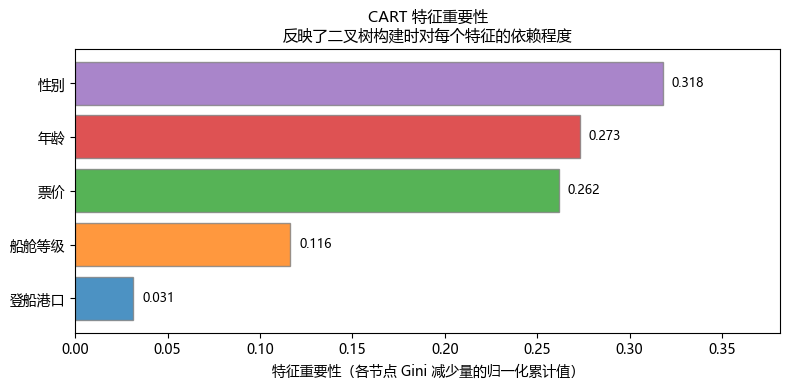

特征重要性排名：
  1. 性别       0.3178  ███████████████
  2. 年龄       0.2730  █████████████
  3. 票价       0.2615  █████████████
  4. 船舱等级     0.1163  █████
  5. 登船港口     0.0314  █

→ 性别是根节点分裂特征，第一刀覆盖全部样本，Gini 减少量最大，重要性最高
  票价隐含社会地位（头等舱票价高 → 优先逃生机会），在树的中层频繁出现
  登船港口与存活关联最弱，树只在深层偶尔用到，重要性最低


In [20]:
# ════════════════════════════════════════════════════════════════════
#  第二步：特征重要性分析
#
#  CART 构建二叉树的每一次分裂，都记录「这个特征在这个节点让 Gini 减少了多少」
#  feature_importances_ 是所有节点上各特征 Gini 减少量的加权求和，归一化后之和 = 1
#
#  直觉：越靠近根节点的分裂，影响的样本数越多，对重要性贡献越大
#  → 如果性别作为根节点特征，第一刀覆盖全部 891 个样本，重要性天然最高
#
#  这张图回答：CART 在一步步构建二叉树时，最依赖哪些特征？
# ════════════════════════════════════════════════════════════════════

# 训练一棵不限深度的深树来提取特征重要性
# 不限深度可以让每个特征充分「发挥」，避免剪枝截断某些特征的贡献
# 此处定义的 dt_deep 后续过拟合诊断步骤也会复用
dt_deep = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_deep.fit(X_train, y_train)

importances = dt_deep.feature_importances_

# 按重要性从高到低排序，方便阅读
sorted_idx   = np.argsort(importances)[::-1]
sorted_names = [feature_names[i] for i in sorted_idx]
sorted_imps  = importances[sorted_idx]

fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.barh(sorted_names[::-1], sorted_imps[::-1],
               color=[f'C{i}' for i in range(len(sorted_names))],
               edgecolor='gray', alpha=0.8)

# 在每个条形右侧标注具体数值
for bar, val in zip(bars, sorted_imps[::-1]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel('特征重要性（各节点 Gini 减少量的归一化累计值）', fontsize=10)
ax.set_title('CART 特征重要性\n反映了二叉树构建时对每个特征的依赖程度', fontsize=11)
ax.set_xlim(0, max(sorted_imps) * 1.2)
plt.tight_layout()
plt.show()

print("特征重要性排名：")
for i, (name, imp) in enumerate(zip(sorted_names, sorted_imps), 1):
    bar_str = "█" * int(imp * 50)
    print(f"  {i}. {name:<8} {imp:.4f}  {bar_str}")

print()
print("→ 性别是根节点分裂特征，第一刀覆盖全部样本，Gini 减少量最大，重要性最高")
print("  票价隐含社会地位（头等舱票价高 → 优先逃生机会），在树的中层频繁出现")
print("  登船港口与存活关联最弱，树只在深层偶尔用到，重要性最低")


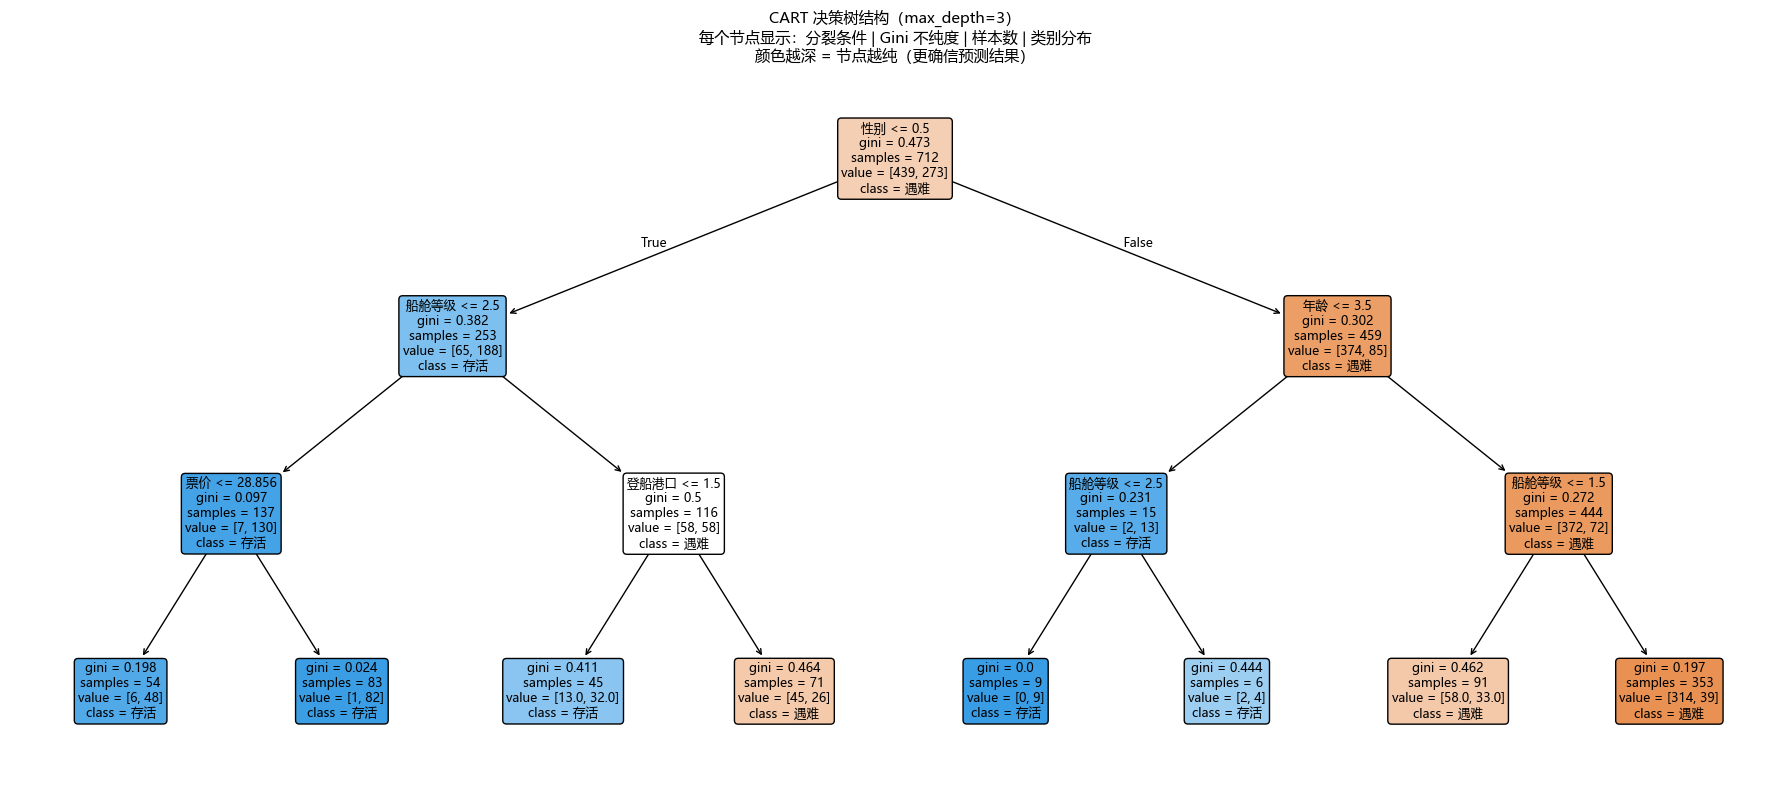


从树结构中读出的核心规则：
  根节点：性别（sex） ≤ 0.5  →  左子树（female=0）存活率高
          性别（sex）  > 0.5  →  右子树（male=1）存活率低
  这与历史记录完全吻合：Titanic 救生艇按'女士优先'原则分配

  → 决策树的最大优点：规则完全透明，可以直接向业务人员解释


In [21]:
# ════════════════════════════════════════════════════════════════════
#  第三步：可视化决策树结构
#  CART 最大优势之一：模型完全透明，每个决策都可以直接读懂
# ════════════════════════════════════════════════════════════════════

# 浅树（剪枝）：限制最大深度为 3
# max_depth=3 意味着从根节点出发最多走 3 步，对应最多 2^3=8 个叶节点
# 这是一种「预剪枝」策略：在构建过程中主动停止，而不是先长满再剪掉
dt_pruned = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
dt_pruned.fit(X_train, y_train)

# 用 max_depth=3 的剪枝树来可视化（深度更大时图会太密集）
fig, ax = plt.subplots(figsize=(18, 8))

plot_tree(
    dt_pruned,
    ax=ax,
    feature_names=feature_names,     # 节点上显示特征的中文名
    class_names=['遇难', '存活'],    # 叶节点上显示类别名称
    filled=True,                      # 按多数类着色：橙=遇难，蓝=存活，颜色越深节点越纯
    impurity=True,                    # 在节点上显示 Gini 不纯度，可看到每次分裂后纯度的变化
    rounded=True,                     # 圆角矩形，美观
    fontsize=9
)

ax.set_title(
    'CART 决策树结构（max_depth=3）\n'
    '每个节点显示：分裂条件 | Gini 不纯度 | 样本数 | 类别分布\n'
    '颜色越深 = 节点越纯（更确信预测结果）',
    fontsize=11
)

plt.tight_layout()
plt.show()

print("\n从树结构中读出的核心规则：")
print("  根节点：性别（sex） ≤ 0.5  →  左子树（female=0）存活率高")
print("          性别（sex）  > 0.5  →  右子树（male=1）存活率低")
print("  这与历史记录完全吻合：Titanic 救生艇按'女士优先'原则分配")
print()
print("  → 决策树的最大优点：规则完全透明，可以直接向业务人员解释")


In [22]:
# ════════════════════════════════════════════════════════════════════
#  第四步：最终模型评估
#  对比深树和剪枝树，输出完整的分类报告
# ════════════════════════════════════════════════════════════════════

print("="*65)
print("  最终模型对比（测试集评估）")
print("="*65)

configs = [
    ('深树（无限深度，过拟合）', {'criterion': 'gini', 'max_depth': None}),
    ('剪枝树（max_depth=3）',    {'criterion': 'gini', 'max_depth': 3}),
]

for desc, params in configs:
    model = DecisionTreeClassifier(**params, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    cv  = cross_val_score(model, X, y, cv=5, scoring='accuracy').mean()

    print(f"\n  ── {desc}")
    print(f"     训练准确率：{train_acc:.3f}  测试准确率：{test_acc:.3f}  差距：{train_acc - test_acc:.3f}")
    print(f"     F1：{f1:.3f}   5折CV均值：{cv:.3f}")

print()
print("─"*65)
print("\n剪枝树的详细分类报告：")
pruned = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
pruned.fit(X_train, y_train)
print(classification_report(
    y_test, pruned.predict(X_test),
    target_names=['遇难（0）', '存活（1）']
))

print("="*65)
print("\n总结：")
print("  CART 通过 Gini 不纯度选择最优分裂，构建严格的二叉树")
print("  max_depth 是最重要的超参数，控制着偏差-方差的权衡")
print("  特征重要性揭示了性别和票价是 Titanic 生存预测的关键因子")
print("  CART 的单树模型是随机森林、XGBoost 等强力集成方法的基础")


  最终模型对比（测试集评估）

  ── 深树（无限深度，过拟合）
     训练准确率：0.980  测试准确率：0.816  差距：0.165
     F1：0.756   5折CV均值：0.782

  ── 剪枝树（max_depth=3）
     训练准确率：0.831  测试准确率：0.777  差距：0.055
     F1：0.655   5折CV均值：0.809

─────────────────────────────────────────────────────────────────

剪枝树的详细分类报告：
              precision    recall  f1-score   support

       遇难（0）       0.77      0.92      0.83       110
       存活（1）       0.81      0.55      0.66        69

    accuracy                           0.78       179
   macro avg       0.79      0.73      0.74       179
weighted avg       0.78      0.78      0.77       179


总结：
  CART 通过 Gini 不纯度选择最优分裂，构建严格的二叉树
  max_depth 是最重要的超参数，控制着偏差-方差的权衡
  特征重要性揭示了性别和票价是 Titanic 生存预测的关键因子
  CART 的单树模型是随机森林、XGBoost 等强力集成方法的基础
